# PREPROCESSING

In [ ]:
!pip install feedparser newspaper3k pandas requests beautifulsoup4 lxml_html_clean Sastrawi
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 50.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.5/81.5 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.1/211.1 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.9/105.9 kB 4.1 MB/s eta 0:00:00
  Created wheel for tinysegmenter: filename=tinysegmenter-0.3-py3-none-any.whl size=13540 sha256=b5ee027aaa0885b7af13a05ce28b5c495044ce20456318905045caaa4c367d92
  Stored in directory: /root/.cache/pip/wheels/a5/91/9f/00d66475960891a64867914273fcaf78df6cb04d905b104a2a
  Created wheel for feedfinder2: filename=feedfinder2-0.0.4-py3-none-any.whl size=3341 sha256=e568556baa767756d8b058d753427c9715a8c1abea38e181482a0e013a1e15f8
  Stored in

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

**Upload file sraped_articles_merged.csv terlebih dahulu**

Handling Missing Values, Lowercasing, Special Char Removal, Punctuations Removal

In [ ]:
import pandas as pd
import re
import numpy as np

file_merged = 'scraped_articles_merged.csv'
try:
    df_result = pd.read_csv(file_merged)
    print(f"File '{file_merged}' berhasil dimuat. Total: {len(df_result)} baris.")
except FileNotFoundError:
    print(f"Error: File tidak ditemukan di {file_merged}. Pastikan file sudah tersedia.")
    df_result = pd.DataFrame()

def clean_text(text):
    if not isinstance(text, str):
        return ""

    # Normalisasi istilah
    text = text.lower()
    text = text.replace('e-commerce', 'ecommerce')
    text = text.replace('tiktok shop', 'tiktokshop')

    # Menghapus teks dalam kurung
    text = re.sub(r'\([^)]*\)', '', text)
    # Menghapus url
    text = re.sub(r'http[s]?://\S+', '', text)
    # Menghapus kata penerbit, kota di awal (sebelum tanda pisah)
    text = re.sub(r'^[^—-]+[-—]\s*', '', text)
    # Menghapus tanggal di awal
    text = re.sub(r'^\d{1,2}\s\w+\s\d{4}\s*[-:]\s*', '', text)
    # Karakter html
    text = re.sub(r'&\w+;', ' ', text)
    text = re.sub(r'&#\d+;', ' ', text)
    # Menghapus angka
    text = re.sub(r'\d+', '', text)
    # Hilangkan emoji dan simbol unicode lainnya
    text = re.sub(r'[^\x00-\x7F]+', ' ', text)
    # Hilangkan tanda baca dan simbol matematika
    text = re.sub(r'[^\w\s]', ' ', text)
    return text

if not df_result.empty:
    df_result['content'] = df_result['content'].fillna('')

    df_result['content_cleaned'] = df_result['content'].apply(clean_text)

    df_result['content_cleaned'] = df_result['content_cleaned'].str.lower()

    df_result['content_cleaned'] = df_result['content_cleaned'].apply(lambda x: re.sub(r'\s+', ' ', x).strip())

    initial_rows = len(df_result)
    df_result = df_result[df_result['content_cleaned'].str.strip() != '']
    rows_removed = initial_rows - len(df_result)

    print(f"Removed {rows_removed} rows with empty content_cleaned after cleaning.")
    display(df_result[['title', 'content', 'content_cleaned']].head())
else:
    print("Tidak ada data untuk diproses.")

File 'scraped_articles_merged.csv' berhasil dimuat. Total: 1053 baris.
Removed 249 rows with empty content_cleaned after cleaning.


,title,content,content_cleaned
0,TikTok raises minimum user age in Indonesia fo...,Jakarta (ANTARA) -\nSocial media giant TikTok ...,social media giant tiktok announced that it ha...
1,TikTok Indonesia Resmi Umumkan Tutup Fitur Tik...,Fitur TikTok Shop resmi ditutup hari ini./\nJa...,tiktokshop mulai hari ini rabu tepatnya pada p...
3,LIVE Tokopedia–TikTok Shop Ditonton 38 Miliar ...,Kementerian Perdagangan mencatat nilai penjual...,kementerian perdagangan mencatat nilai penjual...
4,Konten Jadi Mesin Penggerak Penjualan di Tokop...,Reporter: Dina Mirayanti Hutauruk | Editor: Di...,jakarta tren ecommerce saat ini mengalami perg...
5,usmile Indonesia Berhasil Dominasi Kategori Pr...,@2026 marketing.co.id – All Right Reserved.\nM...,rata pesanan harian hingga dibandingkan period...


Tokenization

In [ ]:
import nltk
from nltk.tokenize import word_tokenize

nltk.download('punkt')
nltk.download('punkt_tab')

def tokenize_text(text):
    if not isinstance(text, str):
        return []
    return word_tokenize(text)

if 'content_cleaned' in df_result.columns:
    df_result['tokenization'] = df_result['content_cleaned'].apply(tokenize_text)
    display(df_result[['title', 'content_cleaned', 'tokenization']].head())
else:
    print("Error: Kolom 'content_cleaned' tidak ditemukan. Jalankan preprocessing terlebih dahulu.")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


,title,content_cleaned,tokenization
0,TikTok raises minimum user age in Indonesia fo...,social media giant tiktok announced that it ha...,"[social, media, giant, tiktok, announced, that..."
1,TikTok Indonesia Resmi Umumkan Tutup Fitur Tik...,tiktokshop mulai hari ini rabu tepatnya pada p...,"[tiktokshop, mulai, hari, ini, rabu, tepatnya,..."
3,LIVE Tokopedia–TikTok Shop Ditonton 38 Miliar ...,kementerian perdagangan mencatat nilai penjual...,"[kementerian, perdagangan, mencatat, nilai, pe..."
4,Konten Jadi Mesin Penggerak Penjualan di Tokop...,jakarta tren ecommerce saat ini mengalami perg...,"[jakarta, tren, ecommerce, saat, ini, mengalam..."
5,usmile Indonesia Berhasil Dominasi Kategori Pr...,rata pesanan harian hingga dibandingkan period...,"[rata, pesanan, harian, hingga, dibandingkan, ..."


Stopwords Removal

In [ ]:
import nltk
from nltk.corpus import stopwords

try:
    stopwords.words('indonesian')
except LookupError:
    nltk.download('stopwords')

stop_words_indonesian = set(stopwords.words('indonesian'))
custom_stopwords = {'nya', 'akan', 'juga', 'pun', 'saja', 'tersebut', 'ini', 'itu', 'adalah', 'dengan', 'dari', 'yang', 'editor', 'reporter'}
stop_words_indonesian.update(custom_stopwords)

def remove_stopwords_from_tokens(tokens_list):
    return [word for word in tokens_list if word not in stop_words_indonesian]

if 'tokenization' in df_result.columns:
    df_result['stopword_removed'] = df_result['tokenization'].apply(remove_stopwords_from_tokens)
    print("Stopword removal selesai. Kolom 'stopword_removed' telah ditambahkan.")
    display(df_result[['title', 'tokenization', 'stopword_removed']].head())
else:
    print("Error: Kolom 'tokenization' tidak ditemukan.")

Stopword removal selesai. Kolom 'stopword_removed' telah ditambahkan.


,title,tokenization,stopword_removed
0,TikTok raises minimum user age in Indonesia fo...,"[social, media, giant, tiktok, announced, that...","[social, media, giant, tiktok, announced, that..."
1,TikTok Indonesia Resmi Umumkan Tutup Fitur Tik...,"[tiktokshop, mulai, hari, ini, rabu, tepatnya,...","[tiktokshop, rabu, tepatnya, wib, resmi, tutup..."
3,LIVE Tokopedia–TikTok Shop Ditonton 38 Miliar ...,"[kementerian, perdagangan, mencatat, nilai, pe...","[kementerian, perdagangan, mencatat, nilai, pe..."
4,Konten Jadi Mesin Penggerak Penjualan di Tokop...,"[jakarta, tren, ecommerce, saat, ini, mengalam...","[jakarta, tren, ecommerce, mengalami, pergeser..."
5,usmile Indonesia Berhasil Dominasi Kategori Pr...,"[rata, pesanan, harian, hingga, dibandingkan, ...","[pesanan, harian, dibandingkan, periode, ramad..."


Stemming

In [ ]:
!pip install Sastrawi
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

factory = StemmerFactory()
stemmer = factory.create_stemmer()

def stem_tokens(tokens_list):
    text = " ".join(tokens_list)
    stemmed_text = stemmer.stem(text)
    # Mengembalikan dalam bentuk list token lagi
    return stemmed_text.split()

if 'stopword_removed' in df_result.columns:
    df_result['stemming_output'] = df_result['stopword_removed'].apply(stem_tokens)
    print("Stemming selesai. Kolom 'stemming_output' telah ditambahkan.")
    display(df_result[['title', 'stopword_removed', 'stemming_output']].head())
else:
    print("Error: Kolom 'stopword_removed' tidak ditemukan.")

Stemming selesai. Kolom 'stemming_output' telah ditambahkan.


,title,stopword_removed,stemming_output
0,TikTok raises minimum user age in Indonesia fo...,"[social, media, giant, tiktok, announced, that...","[social, media, giant, tiktok, announced, that..."
1,TikTok Indonesia Resmi Umumkan Tutup Fitur Tik...,"[tiktokshop, rabu, tepatnya, wib, resmi, tutup...","[tiktokshop, rabu, tepat, wib, resmi, tutup, u..."
3,LIVE Tokopedia–TikTok Shop Ditonton 38 Miliar ...,"[kementerian, perdagangan, mencatat, nilai, pe...","[menteri, dagang, catat, nilai, jual, ecommerc..."
4,Konten Jadi Mesin Penggerak Penjualan di Tokop...,"[jakarta, tren, ecommerce, mengalami, pergeser...","[jakarta, tren, ecommerce, alami, geser, konsu..."
5,usmile Indonesia Berhasil Dominasi Kategori Pr...,"[pesanan, harian, dibandingkan, periode, ramad...","[pesan, hari, banding, periode, ramadan, tren,..."


Rare Words Removal dari Stemming

In [ ]:
from collections import Counter

all_tokens = [token for sublist in df_result['stemming_output'] for token in sublist]
word_freq = Counter(all_tokens)

rare_threshold = 3 # ambang batas
rare_words = {word for word, count in word_freq.items() if count <= rare_threshold}

def remove_rare_words(tokens_list):
    return [word for word in tokens_list if word not in rare_words]

if 'stemming_output' in df_result.columns:
    df_result['stemming_cleaned'] = df_result['stemming_output'].apply(remove_rare_words)

    print(f"Rare words removal selesai.")
    print(f"Jumlah rare words ditemukan (freq <= {rare_threshold}): {len(rare_words)}")
    print("Kolom 'stemming_cleaned' telah ditambahkan sebagai hasil akhir preprocessing.")
    display(df_result[['title', 'stemming_output', 'stemming_cleaned']].head())
else:
    print("Error: Kolom 'stemming_output' tidak ditemukan.")

Rare words removal selesai.
Jumlah rare words ditemukan (freq <= 3): 6471
Kolom 'stemming_cleaned' telah ditambahkan sebagai hasil akhir preprocessing.


,title,stemming_output,stemming_cleaned
0,TikTok raises minimum user age in Indonesia fo...,"[social, media, giant, tiktok, announced, that...","[social, media, giant, tiktok, that, it, has, ..."
1,TikTok Indonesia Resmi Umumkan Tutup Fitur Tik...,"[tiktokshop, rabu, tepat, wib, resmi, tutup, u...","[tiktokshop, rabu, tepat, wib, resmi, tutup, u..."
3,LIVE Tokopedia–TikTok Shop Ditonton 38 Miliar ...,"[menteri, dagang, catat, nilai, jual, ecommerc...","[menteri, dagang, catat, nilai, jual, ecommerc..."
4,Konten Jadi Mesin Penggerak Penjualan di Tokop...,"[jakarta, tren, ecommerce, alami, geser, konsu...","[jakarta, tren, ecommerce, alami, geser, konsu..."
5,usmile Indonesia Berhasil Dominasi Kategori Pr...,"[pesan, hari, banding, periode, ramadan, tren,...","[pesan, hari, banding, periode, ramadan, tren,..."


OUTPUT

In [ ]:
output_file_path = 'scraped_articles_preprocessed.csv'
df_result.to_csv(output_file_path, index=False)
print(f"File preprocessed berhasil disimpan ke: {output_file_path}")

columns_to_show = ['title', 'content_cleaned', 'tokenization', 'stopword_removed', 'stemming_output', 'stemming_cleaned']
display(df_result[columns_to_show].head())

File preprocessed berhasil disimpan ke: scraped_articles_preprocessed.csv


,title,content_cleaned,tokenization,stopword_removed,stemming_output,stemming_cleaned
0,TikTok raises minimum user age in Indonesia fo...,social media giant tiktok announced that it ha...,"[social, media, giant, tiktok, announced, that...","[social, media, giant, tiktok, announced, that...","[social, media, giant, tiktok, announced, that...","[social, media, giant, tiktok, that, it, has, ..."
1,TikTok Indonesia Resmi Umumkan Tutup Fitur Tik...,tiktokshop mulai hari ini rabu tepatnya pada p...,"[tiktokshop, mulai, hari, ini, rabu, tepatnya,...","[tiktokshop, rabu, tepatnya, wib, resmi, tutup...","[tiktokshop, rabu, tepat, wib, resmi, tutup, u...","[tiktokshop, rabu, tepat, wib, resmi, tutup, u..."
3,LIVE Tokopedia–TikTok Shop Ditonton 38 Miliar ...,kementerian perdagangan mencatat nilai penjual...,"[kementerian, perdagangan, mencatat, nilai, pe...","[kementerian, perdagangan, mencatat, nilai, pe...","[menteri, dagang, catat, nilai, jual, ecommerc...","[menteri, dagang, catat, nilai, jual, ecommerc..."
4,Konten Jadi Mesin Penggerak Penjualan di Tokop...,jakarta tren ecommerce saat ini mengalami perg...,"[jakarta, tren, ecommerce, saat, ini, mengalam...","[jakarta, tren, ecommerce, mengalami, pergeser...","[jakarta, tren, ecommerce, alami, geser, konsu...","[jakarta, tren, ecommerce, alami, geser, konsu..."
5,usmile Indonesia Berhasil Dominasi Kategori Pr...,rata pesanan harian hingga dibandingkan period...,"[rata, pesanan, harian, hingga, dibandingkan, ...","[pesanan, harian, dibandingkan, periode, ramad...","[pesan, hari, banding, periode, ramadan, tren,...","[pesan, hari, banding, periode, ramadan, tren,..."


In [ ]:
output_excel_path = 'scraped_articles_preprocessed.xlsx'
df_result.to_excel(output_excel_path, index=False)

NameError: name 'df_result' is not defined

In [2]:
import pandas as pd
from collections import Counter
import ast # Import the ast module

# Load the preprocessed CSV file
preprocessed_df = pd.read_csv('scraped_articles_preprocessed.csv')

# Helper function to safely convert string representation of list to actual list
def safe_literal_eval(x):
    if isinstance(x, str):
        try:
            return ast.literal_eval(x)
        except (ValueError, SyntaxError):
            # If the string is malformed or not a valid literal, return an empty list
            return []
    # If it's not a string (e.g., NaN), return an empty list
    return []

# Ensure the tokenization and stopword_removed columns are treated as lists
# They are stored as strings in CSV, so we need to convert them back to lists
preprocessed_df['tokenization'] = preprocessed_df['tokenization'].apply(safe_literal_eval)
preprocessed_df['stopword_removed'] = preprocessed_df['stopword_removed'].apply(safe_literal_eval)
preprocessed_df['stemming_cleaned'] = preprocessed_df['stemming_cleaned'].apply(safe_literal_eval)

# 1. Number of tokens before stopwords removal
all_tokens_before_stopwords = [token for sublist in preprocessed_df['tokenization'] for token in sublist]
num_tokens_before = len(all_tokens_before_stopwords)
print(f"Total number of tokens before stopwords removal: {num_tokens_before}")

# 2. Number of tokens after stopwords removal
all_tokens_after_stopwords = [token for sublist in preprocessed_df['stopword_removed'] for token in sublist]
num_tokens_after = len(all_tokens_after_stopwords)
print(f"Total number of tokens after stopwords removal: {num_tokens_after}")

# 3. Frequency of top 100 words after stemming and rare words removal
all_stemmed_cleaned_tokens = [token for sublist in preprocessed_df['stemming_cleaned'] for token in sublist]
word_freq = Counter(all_stemmed_cleaned_tokens)

print("\nTop 100 most frequent words (after stemming and rare words removal):")
for word, freq in word_freq.most_common(100):
    print(f"'{word}': {freq}")

Total number of tokens before stopwords removal: 397027
Total number of tokens after stopwords removal: 239467

Top 100 most frequent words (after stemming and rare words removal):
'tiktokshop': 4342
'tiktok': 3778
'jual': 3463
'indonesia': 2764
'umkm': 2746
'produk': 2477
'usaha': 2366
'tokopedia': 2295
'dagang': 2126
'platform': 2066
'pasar': 1934
'ecommerce': 1713
'laku': 1559
'digital': 1464
'perintah': 1290
'beli': 1286
'bisnis': 1244
'atur': 1168
'live': 1096
'guna': 1082
'media': 1056
'tingkat': 1035
'barang': 1021
'milik': 1021
'harga': 1014
'sosial': 987
'konten': 986
'menteri': 974
'lokal': 968
'ekonomi': 951
'iklan': 937
'fitur': 933
'transaksi': 929
'belanja': 884
'tumbuh': 851
'konsumen': 850
'langsung': 840
'online': 840
'hasil': 787
'the': 783
'larang': 765
'tutup': 743
'saing': 727
'salah': 693
'dampak': 673
'langgan': 649
'rp': 638
'program': 637
'aplikasi': 614
'layan': 608
'promosi': 603
'commerce': 600
'nilai': 590
'juta': 584
'kembang': 581
'masyarakat': 566
'manfa

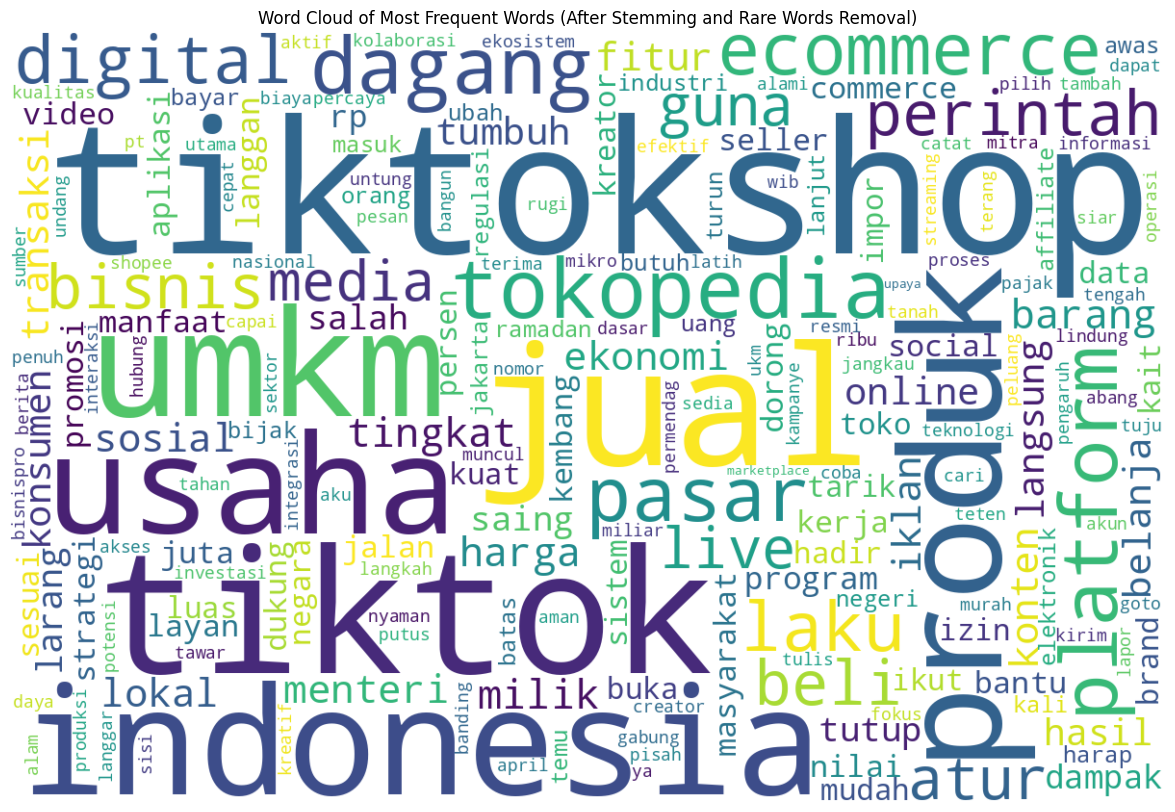

In [5]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Combine all stemmed and cleaned tokens into a single string
text_for_wordcloud = " ".join(all_stemmed_cleaned_tokens)

# Create a WordCloud object
wordcloud = WordCloud(width=1200, height=800, background_color='white', collocations=False).generate(text_for_wordcloud)

# Display the generated image:
plt.figure(figsize=(15, 10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Most Frequent Words (After Stemming and Rare Words Removal)')
plt.show()

Seluruh rangkaian pembersihan data teks telah berhasil diselesaikan dengan tahapan sebagai berikut:
1.  **Pembersihan Teks (Cleaning):** Menghapus simbol, angka, URL, metadata berita, dan normalisasi istilah khusus (seperti `ecommerce` dan `tiktokshop`).
2.  **Tokenisasi:** Memecah teks menjadi potongan kata individual.
3.  **Stopword Removal:** Menghapus kata umum yang tidak memiliki makna signifikan (kata hubung, kata ganti, dll).
4.  **Stemming:** Mengembalikan kata ke bentuk dasarnya menggunakan library Sastrawi.
5.  **Rare Words Removal:** Menghapus kata-kata yang frekuensinya sangat rendah (≤ 3) untuk mengurangi noise pada data.

Data kini siap untuk tahap analisis selanjutnya (TFIDF atau Sentiment Analysis) menggunakan kolom `stemming_cleaned`.